# Transfer learning notebook for fingerprintvalidator project

## Project Pre-requisites

In [37]:
# Import libraries
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import image_dataset_from_directory

In [21]:
# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU (entraînement sera lent)")
except Exception as e:
    print(f"Configuration GPU: {e}")

print(f"\n📦 Versions des bibliothèques :")
print(f"  - TensorFlow : {tf.__version__}")
print(f"  - Keras      : {keras.__version__}")
print(f"  - NumPy      : {np.__version__}")

print(f"\n🚀 Prêt pour le transfer learning en computer vision !")

✅ GPU(s) détecté(s): 1 - Croissance mémoire activée

📦 Versions des bibliothèques :
  - TensorFlow : 2.16.2
  - Keras      : 3.13.2
  - NumPy      : 1.26.4

🚀 Prêt pour le transfer learning en computer vision !


## Project Constants

In [30]:
# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

# Dataset 
DATASET_ROOTDIR_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized" 
print(f"📁 Fingerprints dataset images root directory path : {DATASET_ROOTDIR_PATH}")

DATASET_CSV_PATH = "/Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized_with_labels.csv"
print(f"📁 Fingerprints dataset CSV path : {DATASET_CSV_PATH}")

class_names = ['thumb', 'index', 'middle', 'ring', 'little']
num_classes = len(class_names)
print(f"\n👁️ fingerprints classes : {class_names}")

📁 Fingerprints dataset images root directory path : /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized
📁 Fingerprints dataset CSV path : /Users/laurent/Projects/projet-fingerprint-validator/dataset/SOCOFing_Sanitized_with_labels.csv

👁️ fingerprints classes : ['thumb', 'index', 'middle', 'ring', 'little']


## Fingerprint Dataset Exploration

In [23]:
# load csv
df = pd.read_csv(DATASET_CSV_PATH)

print(f"\n📊 Fingerprints dataset basic stats :")
df.info()


📊 Fingerprints dataset basic stats :
<class 'pandas.DataFrame'>
RangeIndex: 55270 entries, 0 to 55269
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         55270 non-null  int64
 1   ImagePath  55270 non-null  str  
 2   Finger     55270 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.3 MB


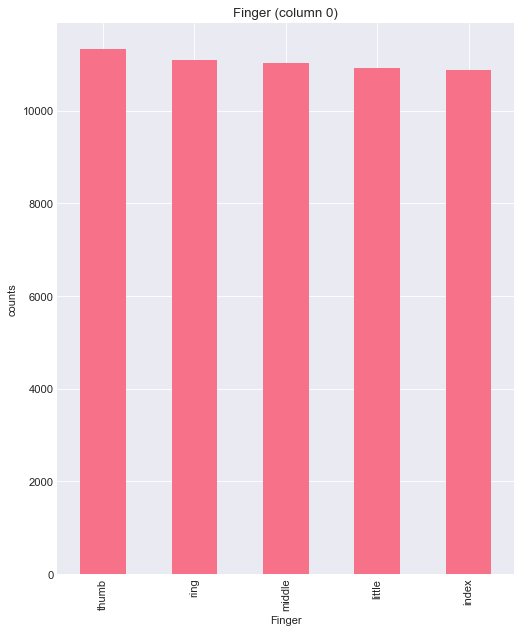

In [24]:
# Distribution graphs (histogram/bar graph) of column data
def plotPerColumnDistribution(df, nGraphShown, nGraphPerRow):
    nunique = df.nunique()
    df = df[[col for col in df if nunique[col] > 1 and nunique[col] < 50]] # For displaying purposes, pick columns that have between 1 and 50 unique values
    nRow, nCol = df.shape
    columnNames = list(df)
    nGraphRow = int((nCol + nGraphPerRow - 1) / nGraphPerRow)
    plt.figure(num = None, figsize = (6 * nGraphPerRow, 8 * nGraphRow), dpi = 80, facecolor = 'w', edgecolor = 'k')
    for i in range(min(nCol, nGraphShown)):
        plt.subplot(nGraphRow, nGraphPerRow, i + 1)
        columnDf = df.iloc[:, i]
        if (not np.issubdtype(type(columnDf.iloc[0]), np.number)):
            valueCounts = columnDf.value_counts()
            valueCounts.plot.bar()
        else:
            columnDf.hist()
        plt.ylabel('counts')
        plt.xticks(rotation = 90)
        plt.title(f'{columnNames[i]} (column {i})')
    plt.tight_layout(pad = 1.0, w_pad = 1.0, h_pad = 1.0)
    plt.show()

# show distribution of columns
plotPerColumnDistribution(df, 10, 5)

In [25]:
# Display of number of thumbs, index, middle, ring, and little fingers
print(f"Percentage of Thumbs: {df['Finger'].value_counts().get('thumb', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Index fingers: {df['Finger'].value_counts().get('index', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Middle fingers: {df['Finger'].value_counts().get('middle', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Ring fingers: {df['Finger'].value_counts().get('ring', 0) / len(df) * 100:.2f}%")
print(f"Percentage of Little fingers: {df['Finger'].value_counts().get('little', 0) / len(df) * 100:.2f}%")

Percentage of Thumbs: 20.50%
Percentage of Index fingers: 19.68%
Percentage of Middle fingers: 19.97%
Percentage of Ring fingers: 20.08%
Percentage of Little fingers: 19.78%


In [ ]:
# List to store file information
imgdata = []

# Traverse the input directory to get all image files
for dirname, _, filenames in os.walk(DATASET_ROOTDIR_PATH):
    for filename in filenames:
            
        file_path = os.path.join(dirname, filename)

        # extract the image features
        img = Image.open(file_path)
        try:
            img.verify()  # Verify that the file is a valid image
        except:
            print(f"Invalid image file: {file_path}")
            continue

        imgdata.append([file_path, img.format, img.size, img.mode])

# Create a DataFrame
imgdf = pd.DataFrame(imgdata, columns=["ImagePath", "ImageFormat", "ImageSize", "ImageMode"])

# Add an index column
imgdf.index.name = "ID"

In [ ]:
# display the dataframe info
imgdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 55270 entries, 0 to 55269
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ImagePath    55270 non-null  str   
 1   ImageFormat  55270 non-null  str   
 2   ImageSize    55270 non-null  object
 3   ImageMode    55270 non-null  str   
dtypes: object(1), str(3)
memory usage: 1.7+ MB


In [28]:
# Display the distribution of ImageFormat, ImageSize, ImageMode
print(imgdf["ImageFormat"].value_counts())
print(imgdf["ImageSize"].value_counts())
print(imgdf["ImageMode"].value_counts())

ImageFormat
JPEG    55270
Name: count, dtype: int64
ImageSize
(224, 224)    55270
Name: count, dtype: int64
ImageMode
RGB    55270
Name: count, dtype: int64


FingerPrint Examples from dataset



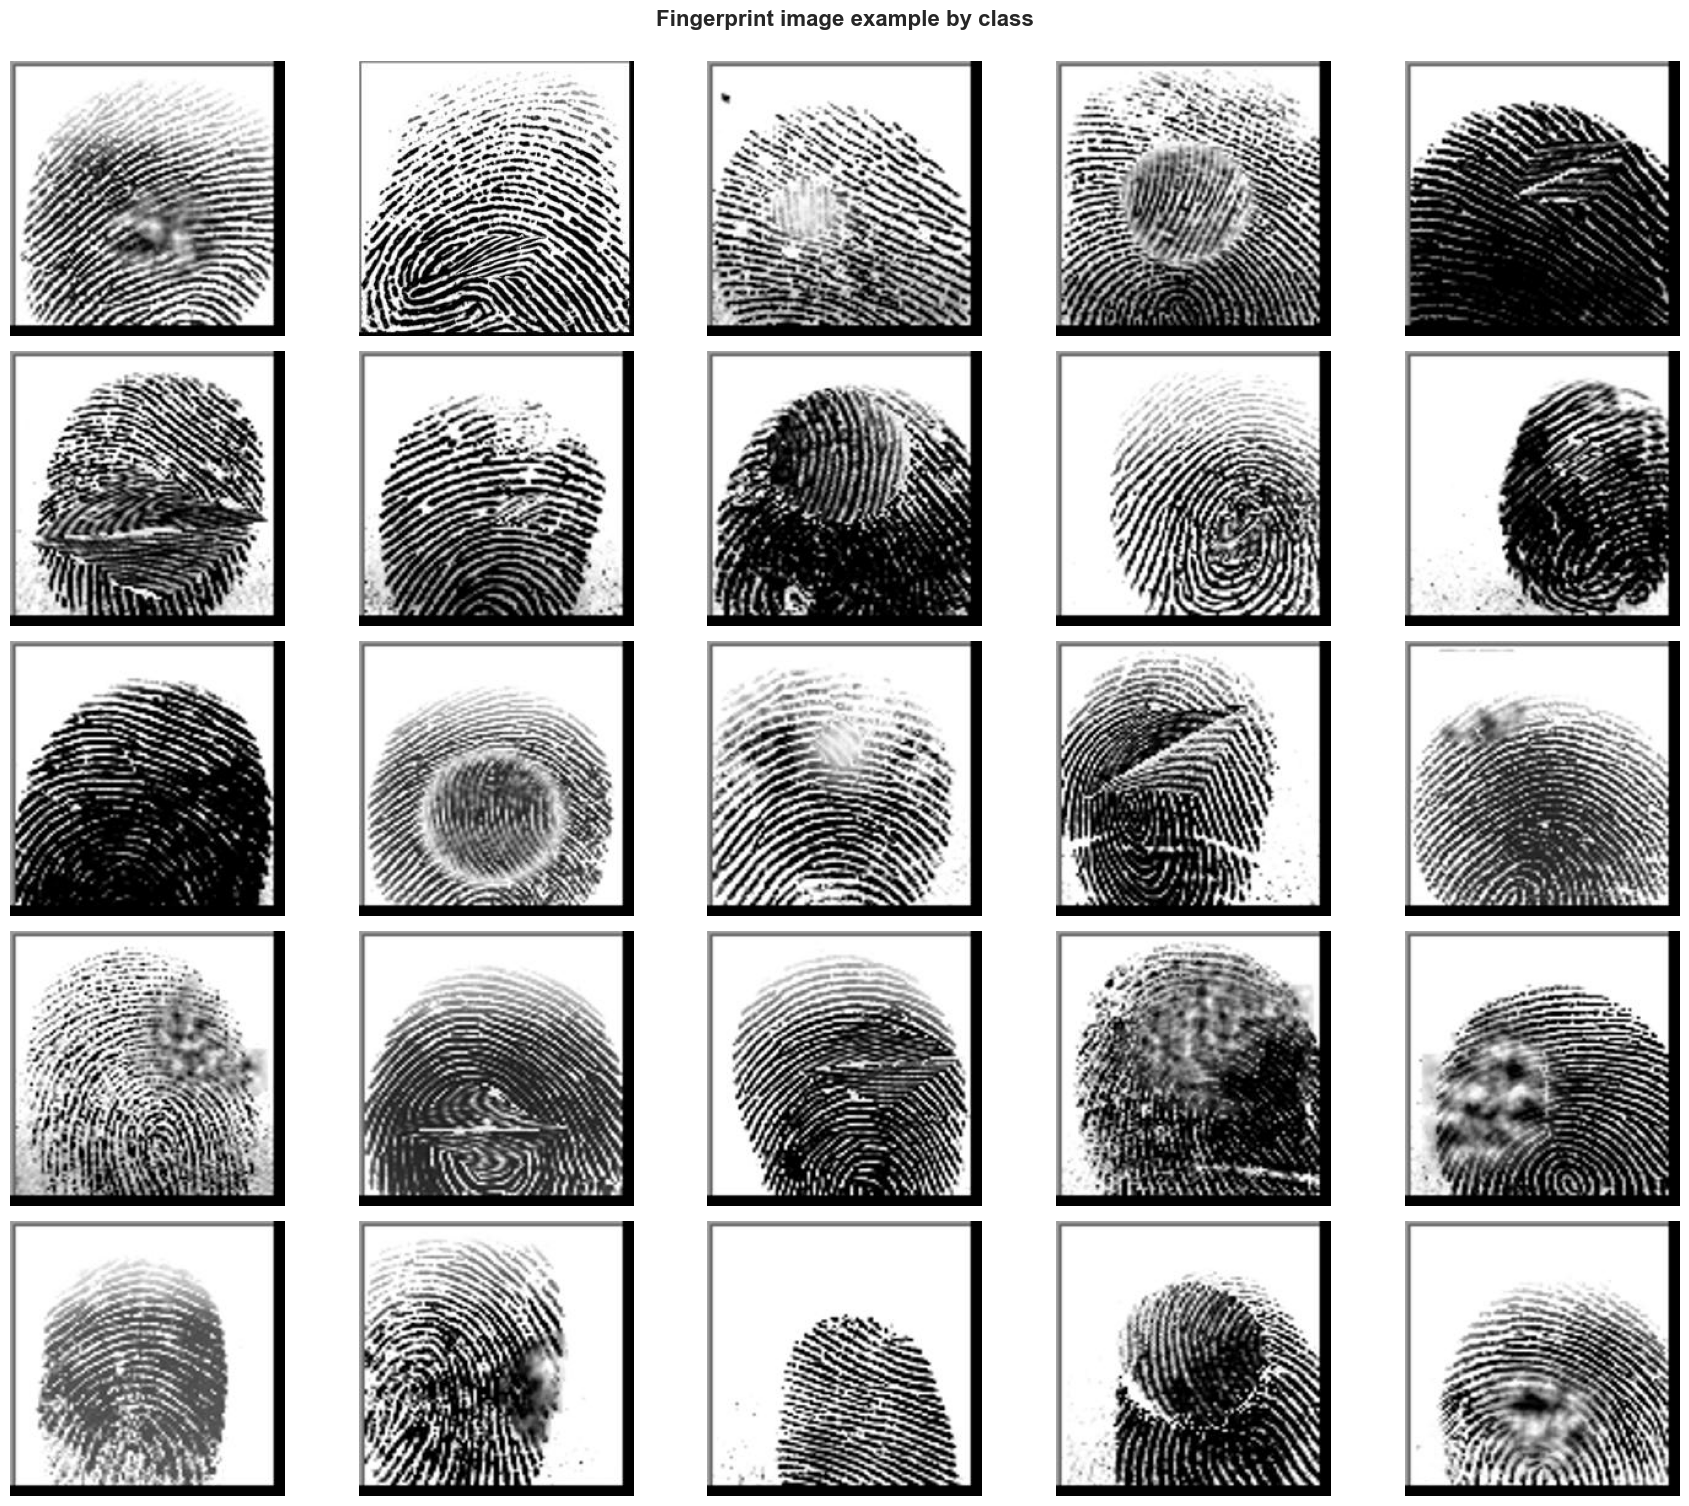

In [38]:
# visualisation of some images
print("FingerPrint Examples from dataset\n")

fig, axes = plt.subplots(num_classes, 5, figsize=(18, 3 * num_classes))

for i, class_name in enumerate(class_names):
    class_path = Path(os.path.join(DATASET_ROOTDIR_PATH, class_name))
    image_files = list(class_path.glob('*.jpeg'))[:5]
    
    for j, img_path in enumerate(image_files):
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_ylabel(class_name.upper(), fontsize=12, fontweight='bold', rotation=0, ha='right', va='center')

plt.suptitle("Fingerprint image example by class", fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

## Prepare Fingerprint dataset for training / validation / test 